# 02 · Noisy and drifting regression (the honest comparison)

Notebook 01 used a clean, fixed task. Real regression is noisy (labels are corrupted) and non-stationary (the target map W moves over time). This notebook pushes MesaNet vs GDN along those two axes and asks where Mesa's exact solve is worth its cost.

Forgetting is fixed here. Both layers keep their memory at the same near-1 rate, so forgetting is not a variable in this notebook. These sweeps isolate noise, drift, and CG compute. Sweeping the forget rate itself comes later.

## How the experiment is set up

- One model per setting. For each (layer, CG, noise, drift) we train a small model at a fixed number of examples and score held-out batches. The swept axes here are noise and drift. All the sweep and plot code is in `compare/experiments.py`.
- Same scoring, via `synthtasks.metrics.mse_on_queries`.
- Forgetting matched near 1 (as in 01): both layers start by keeping about 98% of their memory per step (MESA_RET=4.0 gives decay about 0.982; GDN pinned to the same via `gdn_retention_init`). Without this they would forget at different rates, the confound from 01. Both stay trainable.
- Small, seeded, GPU. Tiny 2-layer models; the fla kernels need CUDA and Triton.

In [11]:
%matplotlib inline
import sys, os
sys.path.insert(0, os.path.abspath(".."))  # project root: makes `compare` importable

import numpy as np
import torch
import matplotlib.pyplot as plt

from compare.experiments import (
    SweepConfig, noise_drift_sweep, plot_mse_vs, plot_cg_family, plot_cg_family_broken,
)

# ----- config (edit here) -----
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE  = torch.bfloat16 if DEVICE == "cuda" else torch.float32   # fla chunk kernels prefer bf16

D, N_EXAMPLES, SEED = 8, 32, 0
NOISE_GRID      = [0.0, 0.1, 0.25, 0.5, 1.0]    # noise sweep (drift fixed = 0)
DRIFT_GRID      = [0.0, 0.02, 0.05, 0.1, 0.2]   # drift sweep (noise fixed below)
NOISE_FOR_DRIFT = 0.25                          # moderate noise held during the drift sweep
CG_GRID         = [1, 2, 5, 10, 30]             # Mesa CG steps (test-time-compute dial)

# --- forgetting held EQUAL and near 1, as in notebook 01 ---
MESA_RET = 4.0                                         # Mesa decay-gate bias
GDN_RET  = float(torch.sigmoid(torch.tensor(MESA_RET)))  # GDN initial decay = σ(4.0) ≈ 0.982
ALL_SPECS = [("mesa", k) for k in CG_GRID] + [("gated_deltanet", None)]

cfg = SweepConfig(
    d=D, batch_size=64, steps=300, lr=3e-3,
    hidden_size=128, num_heads=4, num_layers=2, eval_batches=4,
    dtype=DTYPE, device=DEVICE,
    mesa_retention_init=MESA_RET, gdn_retention_init=GDN_RET,
)
print(f"device={DEVICE}  dtype={DTYPE}  steps={cfg.steps}  n_examples={N_EXAMPLES}  d={D}")
print(f"forgetting held equal & near 1:  Mesa initial decay = σ({MESA_RET}) = {GDN_RET:.3f}"
      f"   GDN initial decay = {GDN_RET:.3f}")

device=cuda  dtype=torch.bfloat16  steps=300  n_examples=32  d=8
forgetting held equal & near 1:  Mesa initial decay = σ(4.0) = 0.982   GDN initial decay = 0.982


## The difficulty knobs: what noise and drift do to the data

A look at the data (no model): noise pushes the target values off the clean line; drift slowly rotates the true map W across the sequence.

In [12]:
from synthtasks.regression import make_regression  # inline dataset inspection

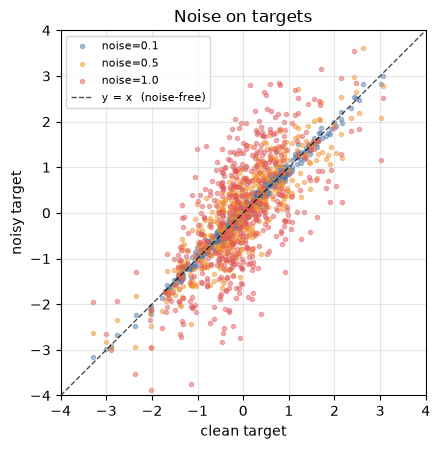

In [13]:
# NOISE: same seed -> identical x and W; only the targets y shift by ~N(0, noise^2).
d_, n_ = 4, 64
_, y_clean, msk = make_regression(batch=8, n_examples=n_, d=d_, noise=0.0, seed=SEED)

fig, ax = plt.subplots(figsize=(5.2, 4.6))
for noise, color in zip([0.1, 0.5, 1.0], ["#4e79a7", "#f28e2b", "#e15759"]):
    _, y_noisy, _ = make_regression(batch=8, n_examples=n_, d=d_, noise=noise, seed=SEED)
    c, ny = y_clean[msk], y_noisy[msk]
    ax.scatter(c, ny, s=9, alpha=0.45, color=color,
               label=f"noise={noise}")
lim = 4.0
ax.plot([-lim, lim], [-lim, lim], "k--", lw=1, alpha=0.7, label="y = x  (noise-free)")
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect("equal")
ax.set_xlabel("clean target")
ax.set_ylabel("noisy target")
ax.set_title("Noise on targets")
ax.legend(fontsize=8, loc="upper left"); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig("figures/02_noise_data.png", dpi=600, bbox_inches="tight"); plt.show()

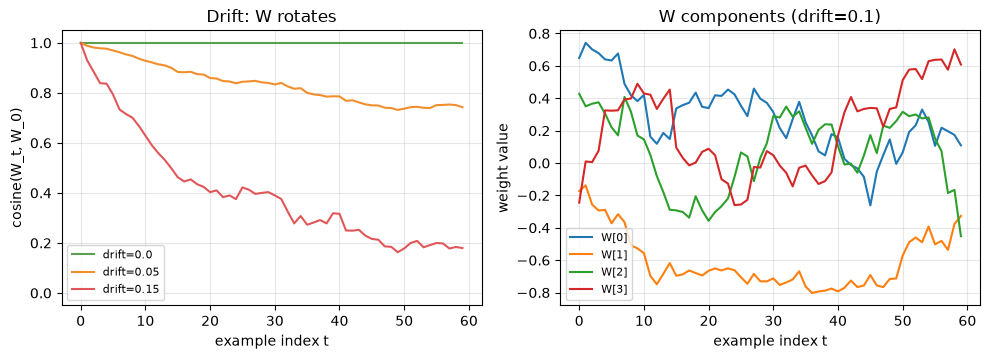

In [14]:
# DRIFT moves the ground-truth map W. Expose W per example (return_weights=True) and
# show it rotating away from its start (cosine to W_0) as drift grows; right: the raw
# components of W wandering across one sequence.
d_, n_ = 4, 60
pos = np.arange(n_)
fig, (axL, axR) = plt.subplots(1, 2, figsize=(10.0, 3.7))

for drift, color in zip([0.0, 0.05, 0.15], ["#59a14f", "#f28e2b", "#e15759"]):
    *_, W = make_regression(batch=64, n_examples=n_, d=d_, noise=0.0, drift=drift,
                            seed=SEED, return_weights=True)
    W0 = W[:, :1, :]
    cos = (W * W0).sum(-1) / (np.linalg.norm(W, axis=-1) * np.linalg.norm(W0, axis=-1) + 1e-9)
    axL.plot(pos, cos.mean(0), color=color, label=f"drift={drift}")
axL.set_ylim(-0.05, 1.05)
axL.set_xlabel("example index t"); axL.set_ylabel("cosine(W_t, W_0)")
axL.set_title("Drift: W rotates")
axL.legend(fontsize=8); axL.grid(True, alpha=0.3)

*_, W = make_regression(batch=1, n_examples=n_, d=d_, noise=0.0, drift=0.1,
                        seed=SEED, return_weights=True)
for j in range(d_):
    axR.plot(pos, W[0, :, j], label=f"W[{j}]")
axR.set_xlabel("example index t"); axR.set_ylabel("weight value")
axR.set_title("W components (drift=0.1)")
axR.legend(fontsize=8); axR.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig("figures/02_drift_data.png", dpi=600, bbox_inches="tight"); plt.show()

In [15]:
def show(rows, x):
    """Compact MSE table: one row per model label, columns = the swept axis `x`."""
    labels = []
    for r in rows:
        if r["label"] not in labels:
            labels.append(r["label"])
    xs = sorted({r[x] for r in rows if r[x] is not None})
    print(f"{x:>16}  " + "  ".join(f"{v:>6}" for v in xs))
    for lb in labels:
        dd = {r[x]: r["mse"] for r in rows if r["label"] == lb}
        body = "  ".join((f"{dd[v]:6.3f}" if v in dd else "    --") for v in xs)
        print(f"{lb:>16}  {body}")

## Noise sweep (drift = 0)

Fix drift = 0 and vary the label-noise level σ. One model per (CG, σ), plus GDN. We show every Mesa CG curve (1, 2, 5, 10, 30) and GDN together on a log-y axis (the σ=1.0 errors are about 3x the rest, so log-y keeps both ends readable).

In [16]:
noise_rows = noise_drift_sweep(ALL_SPECS, NOISE_GRID, [0.0],
                               n_examples=N_EXAMPLES, seed=SEED, cfg=cfg)
print("held-out query MSE  (drift = 0, vary noise):")
show(noise_rows, "noise")

held-out query MSE  (drift = 0, vary noise):
           noise     0.0     0.1    0.25     0.5     1.0
     Mesa (CG=1)   0.419   0.434   0.509   0.747   1.689
     Mesa (CG=2)   0.303   0.324   0.404   0.675   1.722
     Mesa (CG=5)   0.281   0.301   0.373   0.635   1.604
    Mesa (CG=10)   0.288   0.288   0.380   0.635   1.634
    Mesa (CG=30)   0.271   0.290   0.368   0.634   1.588
  Gated DeltaNet   0.299   0.331   0.421   0.696   1.607


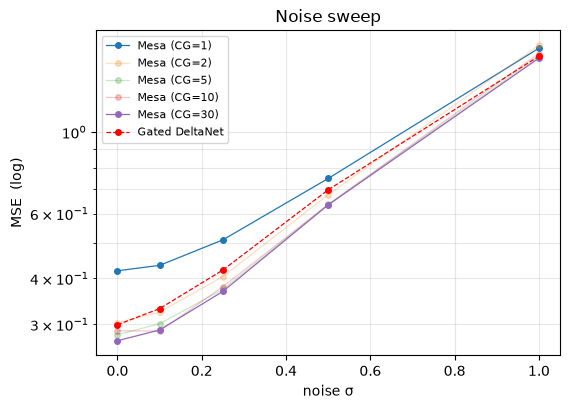

In [17]:
# All curves (every Mesa CG + GDN). Log-y so the σ=1.0 cluster and the σ≤0.5
# detail are both legible on one axis.
ax = plot_mse_vs(noise_rows, "noise",
                 title="Noise sweep",
                 xlabel="noise σ",
                 logy=True, lw=0.9)
plt.tight_layout(); plt.savefig("figures/02_noise_sweep.png", dpi=600, bbox_inches="tight"); plt.show()

### Value of CG steps as noise grows

The same data the other way round: error vs Mesa CG steps, one curve per noise level (GDN is the same-colour dashed line). The y-axis is cut, because the σ=1.0 curves sit about 3x above the rest: they go in a small top panel while the σ up to 0.5 detail spreads out below. That way you can see how much each extra CG step buys at every noise level.

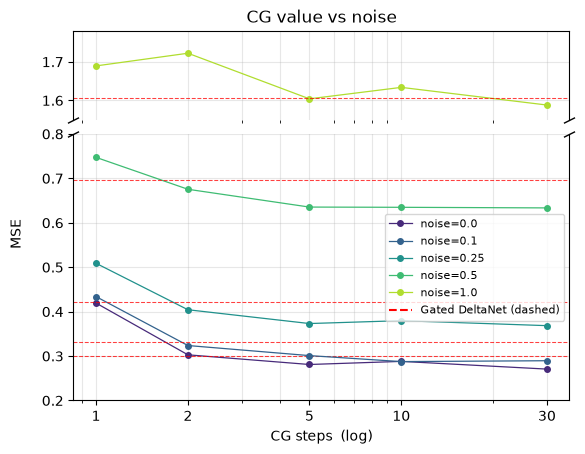

In [18]:
# CUT y-axis: the noise=1.0 family floats at ~1.6, far above the rest, so we break
# the axis - noise=1.0 in the small top panel, the noise≤0.5 detail in the bottom.
top, bot = plot_cg_family_broken(
    noise_rows, "noise",
    lower_ylim=(0.20, 0.80),   # the noise ≤ 0.5 families
    upper_ylim=(1.55, 1.78),   # the far-off noise = 1.0 family
    title="CG value vs noise", lw=0.9)
plt.savefig("figures/02_cg_vs_noise.png", dpi=600, bbox_inches="tight"); plt.show()

## Drift sweep (noise = 0.25)

Hold a moderate noise and vary the drift rate. Forgetting is still fixed near 1 for both layers, so this asks what the exact solve does under drift when neither model is allowed to forget.

In [19]:
drift_rows = noise_drift_sweep(ALL_SPECS, [NOISE_FOR_DRIFT], DRIFT_GRID,
                               n_examples=N_EXAMPLES, seed=SEED, cfg=cfg)
print(f"held-out query MSE  (noise = {NOISE_FOR_DRIFT}, vary drift):")
show(drift_rows, "drift")

held-out query MSE  (noise = 0.25, vary drift):
           drift     0.0    0.02    0.05     0.1     0.2
     Mesa (CG=1)   0.509   0.521   0.602   0.741   0.932
     Mesa (CG=2)   0.404   0.421   0.512   0.686   0.908
     Mesa (CG=5)   0.373   0.398   0.482   0.659   0.910
    Mesa (CG=10)   0.380   0.387   0.485   0.650   0.904
    Mesa (CG=30)   0.368   0.392   0.471   0.653   0.902
  Gated DeltaNet   0.421   0.441   0.513   0.683   0.890


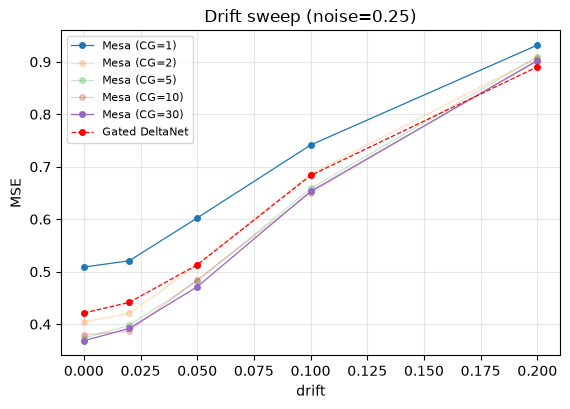

In [20]:
# All curves (every Mesa CG + GDN). Drift MSE spans a narrow range, so a single
# linear axis is legible - no cut needed here.
ax = plot_mse_vs(drift_rows, "drift",
                 title=f"Drift sweep (noise={NOISE_FOR_DRIFT})",
                 xlabel="drift",
                 logy=False, lw=0.9)
plt.tight_layout(); plt.savefig("figures/02_drift_sweep.png", dpi=600, bbox_inches="tight"); plt.show()

### Value of CG steps as drift grows

Error vs Mesa CG steps, one curve per drift level (GDN dashed, same colour).

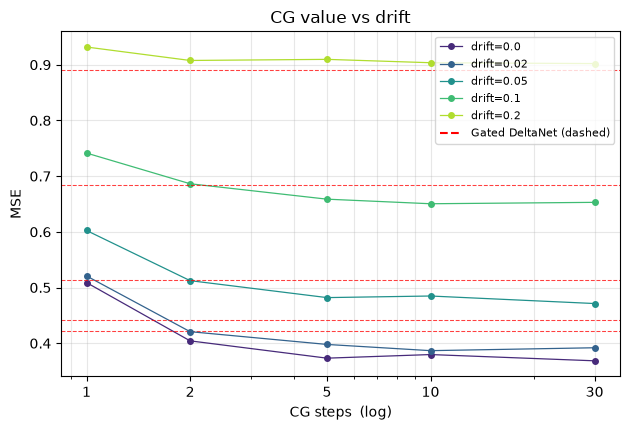

In [21]:
ax = plot_cg_family(drift_rows, "drift",
                    title="CG value vs drift", lw=0.9)
plt.tight_layout(); plt.savefig("figures/02_cg_vs_drift.png", dpi=600, bbox_inches="tight"); plt.show()

## Next: sweep the forget gate

The sweeps above fixed forgetting near 1. Next we let the forget rate δ vary, setting both layers to the same δ:
- Mesa: `mesa_retention_init = logit(δ)` (the a_proj.bias).
- GDN: `gdn_retention_init = δ`.

Both are already wired through the config. The plan: sweep δ in {0.5, 0.8, 0.95, 0.99, 0.999}, focused on drift. The next cells do exactly this.

## Forgetting sweep (noise = 0.25, drift = 0.1)

Sweep the keep-rate δ in {0.5, 0.8, 0.95, 0.99, 0.999} for both layers at one moderate-drift point. The question: with forgetting free to vary, can the right δ let GDN close the gap on Mesa (CG=30)?

- Mesa: `mesa_retention_init = logit(δ)`; GDN: `gdn_retention_init = δ`. Both stay trainable.
- The x-axis is the forget rate 1-δ on a log scale (left = forget fast, right = keep everything).

In [22]:
import math as _math

DELTA_GRID  = [0.5, 0.8, 0.95, 0.99, 0.999]   # log-spaced in forget rate 1-δ
NOISE_FGT   = 0.25
DRIFT_FGT   = 0.1

print(f"Forgetting sweep  noise={NOISE_FGT}  drift={DRIFT_FGT}  Mesa CG=30")
print(f"  δ grid: {DELTA_GRID}  (forget rate = 1−δ: {[round(1-d,4) for d in DELTA_GRID]})")

fgt_rows = []
for delta in DELTA_GRID:
    mesa_bias = _math.log(delta / (1.0 - delta))   # logit(δ) → mesa_retention_init
    cfg_d = SweepConfig(
        d=D, batch_size=cfg.batch_size, steps=cfg.steps, lr=cfg.lr,
        hidden_size=cfg.hidden_size, num_heads=cfg.num_heads, num_layers=cfg.num_layers,
        eval_batches=cfg.eval_batches, dtype=cfg.dtype, device=cfg.device,
        mesa_retention_init=mesa_bias, gdn_retention_init=float(delta),
    )
    for r in noise_drift_sweep([("mesa", 30), ("gated_deltanet", None)],
                                [NOISE_FGT], [DRIFT_FGT],
                                n_examples=N_EXAMPLES, seed=SEED, cfg=cfg_d):
        r["delta"]       = float(delta)
        r["forget_rate"] = round(1.0 - float(delta), 4)
        fgt_rows.append(r)

print("\nheld-out query MSE  (forget rate = 1−δ):")
show(fgt_rows, "forget_rate")

Forgetting sweep  noise=0.25  drift=0.1  Mesa CG=30
  δ grid: [0.5, 0.8, 0.95, 0.99, 0.999]  (forget rate = 1−δ: [0.5, 0.2, 0.05, 0.01, 0.001])

held-out query MSE  (forget rate = 1−δ):
     forget_rate   0.001    0.01    0.05     0.2     0.5
    Mesa (CG=30)   0.701   0.653   0.655   0.661   0.687
  Gated DeltaNet   0.676   0.679   0.705   0.724   0.718


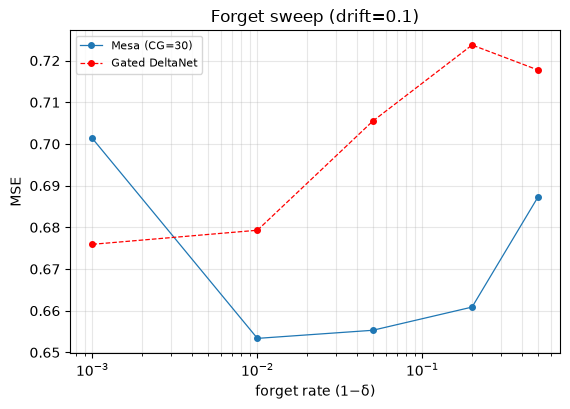

In [23]:
ax = plot_mse_vs(fgt_rows, "forget_rate",
                 title=f"Forget sweep (drift={DRIFT_FGT})",
                 xlabel="forget rate (1−δ)",
                 logy=False, logx=True, lw=0.9)
plt.tight_layout(); plt.savefig("figures/02_forget_drift01.png", dpi=600, bbox_inches="tight"); plt.show()

### Do we also need to sweep CG here?

Not for this question. We fix Mesa at CG=30 (its strongest setting) on purpose, to ask one clean thing: given Mesa at full strength, can tuning the forget gate let cheap GDN catch up? The full δ-by-CG surface is the δ-by-CG experiment (now notebook 03, section C).

## Forgetting sweep at stronger drift (drift = 0.2)

Re-run the δ sweep at drift = 0.2. Both layers share the same δ; Mesa stays at CG=30, so this isolates forgetting.

In [24]:
import math as _math

DELTA_GRID2     = [0.5, 0.8, 0.95, 0.99, 0.999]   # log-spaced in forget rate 1−δ (as before)
NOISE_F2, DRIFT_F2 = 0.25, 0.20                   # the operating point where GDN inverts past pinned-δ Mesa

print(f"Forgetting sweep  noise={NOISE_F2}  drift={DRIFT_F2}  Mesa CG=30 vs GDN")
print(f"  δ grid: {DELTA_GRID2}  (forget rate = 1−δ: {[round(1-d,4) for d in DELTA_GRID2]})")

fgt2_rows = []
for delta in DELTA_GRID2:
    mesa_bias = _math.log(delta / (1.0 - delta))   # logit(δ) → mesa_retention_init
    cfg_d = SweepConfig(
        d=D, batch_size=cfg.batch_size, steps=cfg.steps, lr=cfg.lr,
        hidden_size=cfg.hidden_size, num_heads=cfg.num_heads, num_layers=cfg.num_layers,
        eval_batches=cfg.eval_batches, dtype=cfg.dtype, device=cfg.device,
        mesa_retention_init=mesa_bias, gdn_retention_init=float(delta),
    )
    for r in noise_drift_sweep([("mesa", 30), ("gated_deltanet", None)],
                                [NOISE_F2], [DRIFT_F2],
                                n_examples=N_EXAMPLES, seed=SEED, cfg=cfg_d):
        r["delta"]       = float(delta)
        r["forget_rate"] = round(1.0 - float(delta), 4)
        fgt2_rows.append(r)

print("\nheld-out query MSE  (forget rate = 1−δ):")
show(fgt2_rows, "forget_rate")

Forgetting sweep  noise=0.25  drift=0.2  Mesa CG=30 vs GDN
  δ grid: [0.5, 0.8, 0.95, 0.99, 0.999]  (forget rate = 1−δ: [0.5, 0.2, 0.05, 0.01, 0.001])

held-out query MSE  (forget rate = 1−δ):
     forget_rate   0.001    0.01    0.05     0.2     0.5
    Mesa (CG=30)   0.919   0.914   0.895   0.906   0.925
  Gated DeltaNet   0.893   0.907   0.912   0.909   0.913


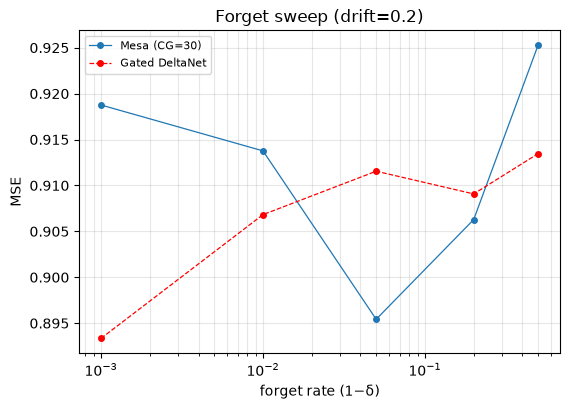

In [25]:
ax = plot_mse_vs(fgt2_rows, "forget_rate",
                 title=f"Forget sweep (drift={DRIFT_F2})",
                 xlabel="forget rate (1−δ)",
                 logy=False, logx=True, lw=0.9)
plt.tight_layout(); plt.savefig("figures/02_forget_drift02.png", dpi=600, bbox_inches="tight"); plt.show()

## Regularization sweep under noise (Λ at noise = 1.0)

Why Λ, and why at high noise. Drift and noise break the exact solve differently. Drift is about stale data, so the fix is forgetting (above). Noise is about variance: the exact solve fits whatever labels it is given, so corrupted labels make it over-fit. The textbook fix is ridge regularization, shrinking the solution. Mesa's ridge is exactly its Λ, which we froze into a sweepable knob in notebook 01b.

Forgetting stays fixed near 1 and Mesa stays at CG=30, so Λ is the only thing changing.

In [26]:
LAMBDA_GRID = [0.25, 1, 4, 16, 50, 200]   # ridge magnitude, as in notebook 01b
NOISE_L     = 1.0                          # heavy noise: where Mesa's edge has collapsed (see extended-noise note)

print(f"Λ (ridge) sweep   noise={NOISE_L}  drift=0   Mesa CG=30, forgetting pinned near 1")
lam_rows = []
for L in LAMBDA_GRID:
    cfg_L = SweepConfig(
        d=D, batch_size=cfg.batch_size, steps=cfg.steps, lr=cfg.lr,
        hidden_size=cfg.hidden_size, num_heads=cfg.num_heads, num_layers=cfg.num_layers,
        eval_batches=cfg.eval_batches, dtype=cfg.dtype, device=cfg.device,
        mesa_retention_init=MESA_RET, gdn_retention_init=GDN_RET,
        mesa_lambda=float(L),          # pin & freeze Mesa's ridge Λ at this value
    )
    r = noise_drift_sweep([("mesa", 30)], [NOISE_L], [0.0],
                          n_examples=N_EXAMPLES, seed=SEED, cfg=cfg_L)[0]
    r["lambda"] = float(L)
    lam_rows.append(r)

# GDN reference is Λ-independent (mesa_lambda is ignored for non-Mesa layers): one run.
gdn_ref = noise_drift_sweep([("gated_deltanet", None)], [NOISE_L], [0.0],
                            n_examples=N_EXAMPLES, seed=SEED, cfg=cfg)[0]["mse"]

print(f"\n{'Λ':>8} {'Mesa MSE':>9}")
for r in lam_rows:
    print(f"{r['lambda']:>8} {r['mse']:>9.3f}")
print(f"{'GDN ref':>8} {gdn_ref:>9.3f}")

Λ (ridge) sweep   noise=1.0  drift=0   Mesa CG=30, forgetting pinned near 1

       Λ  Mesa MSE
    0.25     1.600
     1.0     1.605
     4.0     1.595
    16.0     1.772
    50.0     1.632
   200.0     1.655
 GDN ref     1.607


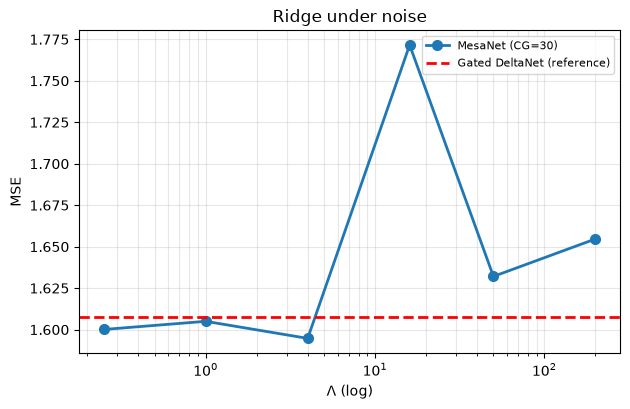

In [27]:
lams = np.array([r["lambda"] for r in lam_rows], dtype=float)
mse  = np.array([r["mse"] for r in lam_rows], dtype=float)

plt.figure(figsize=(6.4, 4.2))
plt.semilogx(lams, mse, "o-", color="C0", lw=2, ms=7, label="MesaNet (CG=30)")
plt.axhline(gdn_ref, color="r", ls="--", lw=2, label="Gated DeltaNet (reference)")
plt.xlabel("Λ (log)")
plt.ylabel("MSE")
plt.title("Ridge under noise")
plt.legend(fontsize=8)
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.savefig("figures/02_lambda_noise.png", dpi=600, bbox_inches="tight"); plt.show()

## Follow-up: Λ by n_examples

Fix heavy noise (σ=1.0) and sweep Λ by n_examples, with n from 8 (=d) up to 48. Left panel: error vs Λ per n. Right panel: gain from tuning Λ vs n.

> Cost: the most expensive cell here (about 42 small trainings). Trim the grids for a quick look.

In [28]:
NOISE_LN  = 1.0                              # fixed heavy noise (as in the Λ-only sweep above)
N_GRID    = [8, 12, 16, 24, 32, 48]          # in-context examples, spanning n ≈ d (=8) → n ≫ d
LAMBDA_LN = [0.25, 1, 4, 16, 50, 200]        # ridge magnitude

print(f"Λ × n_examples   noise={NOISE_LN}  drift=0   Mesa CG=30   (d={D})")
print("(heaviest cell: 6 n × 6 Λ + 6 GDN ≈ 42 small trainings)")
ln_mse, ln_gdn = {}, {}
for n in N_GRID:
    row = []
    for L in LAMBDA_LN:
        cfg_nL = SweepConfig(
            d=D, batch_size=cfg.batch_size, steps=cfg.steps, lr=cfg.lr,
            hidden_size=cfg.hidden_size, num_heads=cfg.num_heads, num_layers=cfg.num_layers,
            eval_batches=cfg.eval_batches, dtype=cfg.dtype, device=cfg.device,
            mesa_retention_init=MESA_RET, gdn_retention_init=GDN_RET, mesa_lambda=float(L),
        )
        row.append(noise_drift_sweep([("mesa", 30)], [NOISE_LN], [0.0],
                                     n_examples=n, seed=SEED, cfg=cfg_nL)[0]["mse"])
    ln_mse[n] = row
    ln_gdn[n] = noise_drift_sweep([("gated_deltanet", None)], [NOISE_LN], [0.0],
                                  n_examples=n, seed=SEED, cfg=cfg)[0]["mse"]
    star = LAMBDA_LN[int(np.argmin(row))]
    print(f"  n={n:>3}: " + "  ".join(f"{m:5.3f}" for m in row)
          + f"   | GDN {ln_gdn[n]:5.3f}   best Λ={star}")

Λ × n_examples   noise=1.0  drift=0   Mesa CG=30   (d=8)
(heaviest cell: 6 n × 6 Λ + 6 GDN ≈ 42 small trainings)
  n=  8: 2.021  2.022  2.045  2.024  2.033  2.023   | GDN 1.955   best Λ=0.25
  n= 12: 1.980  1.992  1.998  2.014  1.998  2.029   | GDN 1.857   best Λ=0.25
  n= 16: 1.843  1.832  1.915  1.931  1.972  1.955   | GDN 1.819   best Λ=1
  n= 24: 1.723  1.709  1.712  1.725  1.726  1.875   | GDN 1.685   best Λ=1
  n= 32: 1.600  1.605  1.595  1.772  1.632  1.655   | GDN 1.607   best Λ=4
  n= 48: 1.464  1.450  1.488  1.497  1.503  1.497   | GDN 1.497   best Λ=1


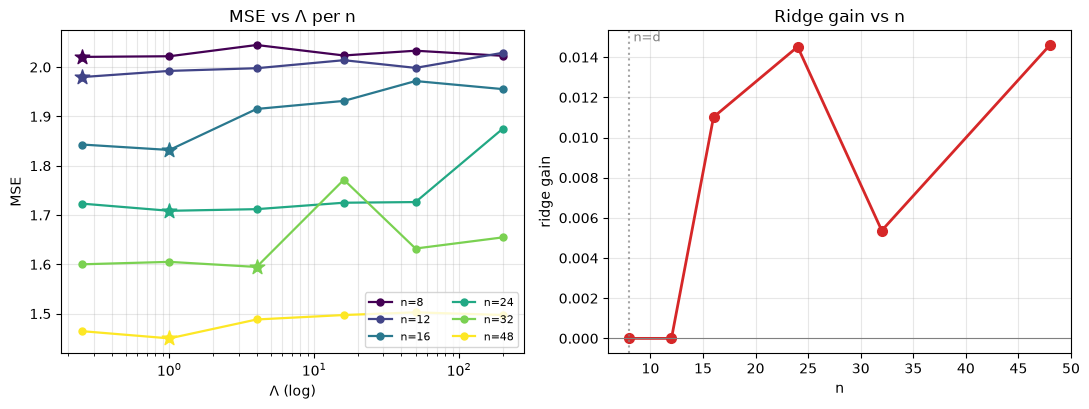

In [29]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.2))
colors = plt.cm.viridis(np.linspace(0, 1, len(N_GRID)))
lam = np.array(LAMBDA_LN, dtype=float)

for c, n in zip(colors, N_GRID):
    m = np.array(ln_mse[n], dtype=float)
    axL.semilogx(lam, m, "o-", color=c, lw=1.6, ms=5, label=f"n={n}")
    axL.scatter([lam[m.argmin()]], [m.min()], color=c, s=120, marker="*", zorder=5)
axL.set_xlabel("Λ (log)")
axL.set_ylabel("MSE")
axL.set_title("MSE vs Λ per n")
axL.legend(fontsize=8, ncol=2)
axL.grid(True, which="both", alpha=0.3)

# "regularization gain" = MSE at the least-regularized end − best MSE over Λ
gain = [ln_mse[n][0] - min(ln_mse[n]) for n in N_GRID]
axR.plot(N_GRID, gain, "o-", color="C3", lw=2, ms=7)
axR.axhline(0, color="gray", lw=0.8)
axR.axvline(D, color="gray", ls=":", alpha=0.7)
axR.text(D, axR.get_ylim()[1], " n=d", va="top", color="gray", fontsize=9)
axR.set_xlabel("n")
axR.set_ylabel("ridge gain")
axR.set_title("Ridge gain vs n")
axR.grid(True, alpha=0.3)

plt.tight_layout(); plt.savefig("figures/02_lambda_x_n.png", dpi=600, bbox_inches="tight"); plt.show()

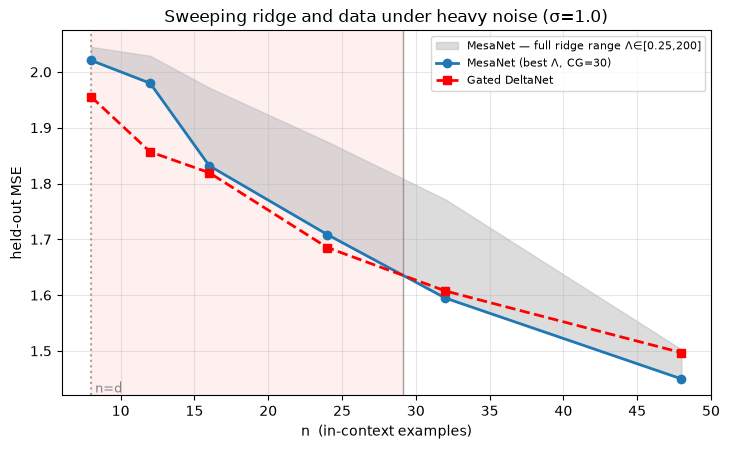

max MSE spread across ALL Λ at fixed n : 0.177  (ridge effect)
MSE drop from n=8 to n=48 (best Mesa)  : 0.571  (data effect)
best-Mesa vs GDN crossover at n ~ 29  (~3.6d)


In [32]:
# One figure, two messages: (1) ridge is inert, (2) Mesa needs data.
# Reuses ln_mse / ln_gdn / N_GRID / D from the Λ×n sweep above.
best_mesa  = np.array([min(ln_mse[n]) for n in N_GRID])   # Mesa at its best Λ
worst_mesa = np.array([max(ln_mse[n]) for n in N_GRID])   # Mesa at its worst Λ
gdn_line   = np.array([ln_gdn[n]      for n in N_GRID])
nn         = np.array(N_GRID, dtype=float)

# best-Mesa vs GDN crossover, on a fine grid
xf = np.linspace(nn.min(), nn.max(), 400)
bm, gd = np.interp(xf, nn, best_mesa), np.interp(xf, nn, gdn_line)
xcross = float(xf[np.argmin(np.abs(bm - gd))])

fig, ax = plt.subplots(figsize=(7.4, 4.6))

# (1) RIDGE IS NOT THE LEVER: the entire Λ∈[0.25,200] range is this thin band.
ax.fill_between(nn, worst_mesa, best_mesa, color="0.7", alpha=0.45, zorder=1,
                label="MesaNet — full ridge range Λ∈[0.25,200]")
ax.plot(nn, best_mesa, "o-", color="C0", lw=2, ms=6, zorder=3,
        label="MesaNet (best Λ, CG=30)")
ax.plot(nn, gdn_line, "s--", color="r", lw=2, ms=6, zorder=3,
        label="Gated DeltaNet")

# (2) MESA LOSES ON LOW DATA: shade the data-scarce region where GDN wins.
ax.axvspan(nn.min(), xcross, color="r", alpha=0.06, zorder=0)
ax.axvline(xcross, color="gray", lw=1, alpha=0.7, zorder=2)
ax.axvline(D, color="gray", ls=":", alpha=0.7)
ax.text(D, ax.get_ylim()[0], " n=d", va="bottom", color="gray", fontsize=9)

ax.set_xlabel("n  (in-context examples)")
ax.set_ylabel("held-out MSE")
ax.set_title("Sweeping ridge and data under heavy noise (σ=1.0)")
ax.legend(fontsize=8, loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figures/02_ridge_inert_data_crossover.png", dpi=600, bbox_inches="tight")
plt.show()

print(f"max MSE spread across ALL Λ at fixed n : {float((worst_mesa - best_mesa).max()):.3f}  (ridge effect)")
print(f"MSE drop from n=8 to n=48 (best Mesa)  : {float(best_mesa[0] - best_mesa[-1]):.3f}  (data effect)")
print(f"best-Mesa vs GDN crossover at n ~ {xcross:.0f}  (~{xcross / D:.1f}d)")
